## About Dataset

Data Description
7043 observations with 33 variables

CustomerID: A unique ID that identifies each customer.

Count: A value used in reporting/dashboarding to sum up the number of customers in a filtered set.

Country: The country of the customer’s primary residence.

State: The state of the customer’s primary residence.

City: The city of the customer’s primary residence.

Zip Code: The zip code of the customer’s primary residence.

Lat Long: The combined latitude and longitude of the customer’s primary residence.

Latitude: The latitude of the customer’s primary residence.

Longitude: The longitude of the customer’s primary residence.

Gender: The customer’s gender: Male, Female

Senior Citizen: Indicates if the customer is 65 or older: Yes, No

Partner: Indicate if the customer has a partner: Yes, No

Dependents: Indicates if the customer lives with any dependents: Yes, No. Dependents could be children, parents, grandparents, etc.

Tenure Months: Indicates the total amount of months that the customer has been with the company by the end of the quarter specified above.

Phone Service: Indicates if the customer subscribes to home phone service with the company: Yes, No

Multiple Lines: Indicates if the customer subscribes to multiple telephone lines with the company: Yes, No

Internet Service: Indicates if the customer subscribes to Internet service with the company: No, DSL, Fiber Optic, Cable.

Online Security: Indicates if the customer subscribes to an additional online security service provided by the company: Yes, No

Online Backup: Indicates if the customer subscribes to an additional online backup service provided by the company: Yes, No

Device Protection: Indicates if the customer subscribes to an additional device protection plan for their Internet equipment provided by the company: Yes, No

Tech Support: Indicates if the customer subscribes to an additional technical support plan from the company with reduced wait times: Yes, No

Streaming TV: Indicates if the customer uses their Internet service to stream television programing from a third party provider: Yes, No. The company does not charge an additional fee for this service.

Streaming Movies: Indicates if the customer uses their Internet service to stream movies from a third party provider: Yes, No. The company does not charge an additional fee for this service.

Contract: Indicates the customer’s current contract type: Month-to-Month, One Year, Two Year.

Paperless Billing: Indicates if the customer has chosen paperless billing: Yes, No

Payment Method: Indicates how the customer pays their bill: Bank Withdrawal, Credit Card, Mailed Check

Monthly Charge: Indicates the customer’s current total monthly charge for all their services from the company.

Total Charges: Indicates the customer’s total charges, calculated to the end of the quarter specified above.

Churn Label: Yes = the customer left the company this quarter. No = the customer remained with the company. Directly related to Churn Value.

Churn Value: 1 = the customer left the company this quarter. 0 = the customer remained with the company. Directly related to Churn Label.

Churn Score: A value from 0-100 that is calculated using the predictive tool IBM SPSS Modeler. The model incorporates multiple factors known to cause churn. The higher the score, the more likely the customer will churn.

CLTV: Customer Lifetime Value. A predicted CLTV is calculated using corporate formulas and existing data. The higher the value, the more valuable the customer. High value customers should be monitored for churn.

Churn Reason: A customer’s specific reason for leaving the company. Directly related to Churn Category.

In [2]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import (precision_score, recall_score, f1_score)
from sklearn.model_selection import StratifiedKFold, cross_val_score


In [3]:
xl_file = pd.read_excel("../data/Telco_customer_churn.xlsx")
xl_file.to_csv("../data/Telco_customer_churn.csv", index=False)



In [4]:
dataframe = pd.read_csv("../data/Telco_customer_churn.csv")
df = dataframe.copy()

In [5]:
pd.set_option('display.max_columns', None)

In [6]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [8]:
for col in df.columns:
    print(f"--- Value Counts for {col} ---")
    print(df[col].value_counts())
    print("\n")  # Adds a blank line between columns for readability


--- Value Counts for CustomerID ---
CustomerID
3668-QPYBK    1
9237-HQITU    1
9305-CDSKC    1
7892-POOKP    1
0280-XJGEX    1
             ..
2569-WGERO    1
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64


--- Value Counts for Count ---
Count
1    7043
Name: count, dtype: int64


--- Value Counts for Country ---
Country
United States    7043
Name: count, dtype: int64


--- Value Counts for State ---
State
California    7043
Name: count, dtype: int64


--- Value Counts for City ---
City
Los Angeles       305
San Diego         150
San Jose          112
Sacramento        108
San Francisco     104
                 ... 
Milford             4
Calpine             4
Standish            4
Tulelake            4
Olympic Valley      4
Name: count, Length: 1129, dtype: int64


--- Value Counts for Zip Code ---
Zip Code
90003    5
90005    5
90006    5
90010    5
90015    5
        ..
96121    4
96124    4
96128    4
96134    4
96146    4
Na

here some columns datatypes are categorized wrong
1. total charges should be numerical column (float)
2. longitude and  should be in numerical

also we dont need some columnns we will select the most important. columns. for base model
1. essential dropinng customer columnn


In [9]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
  

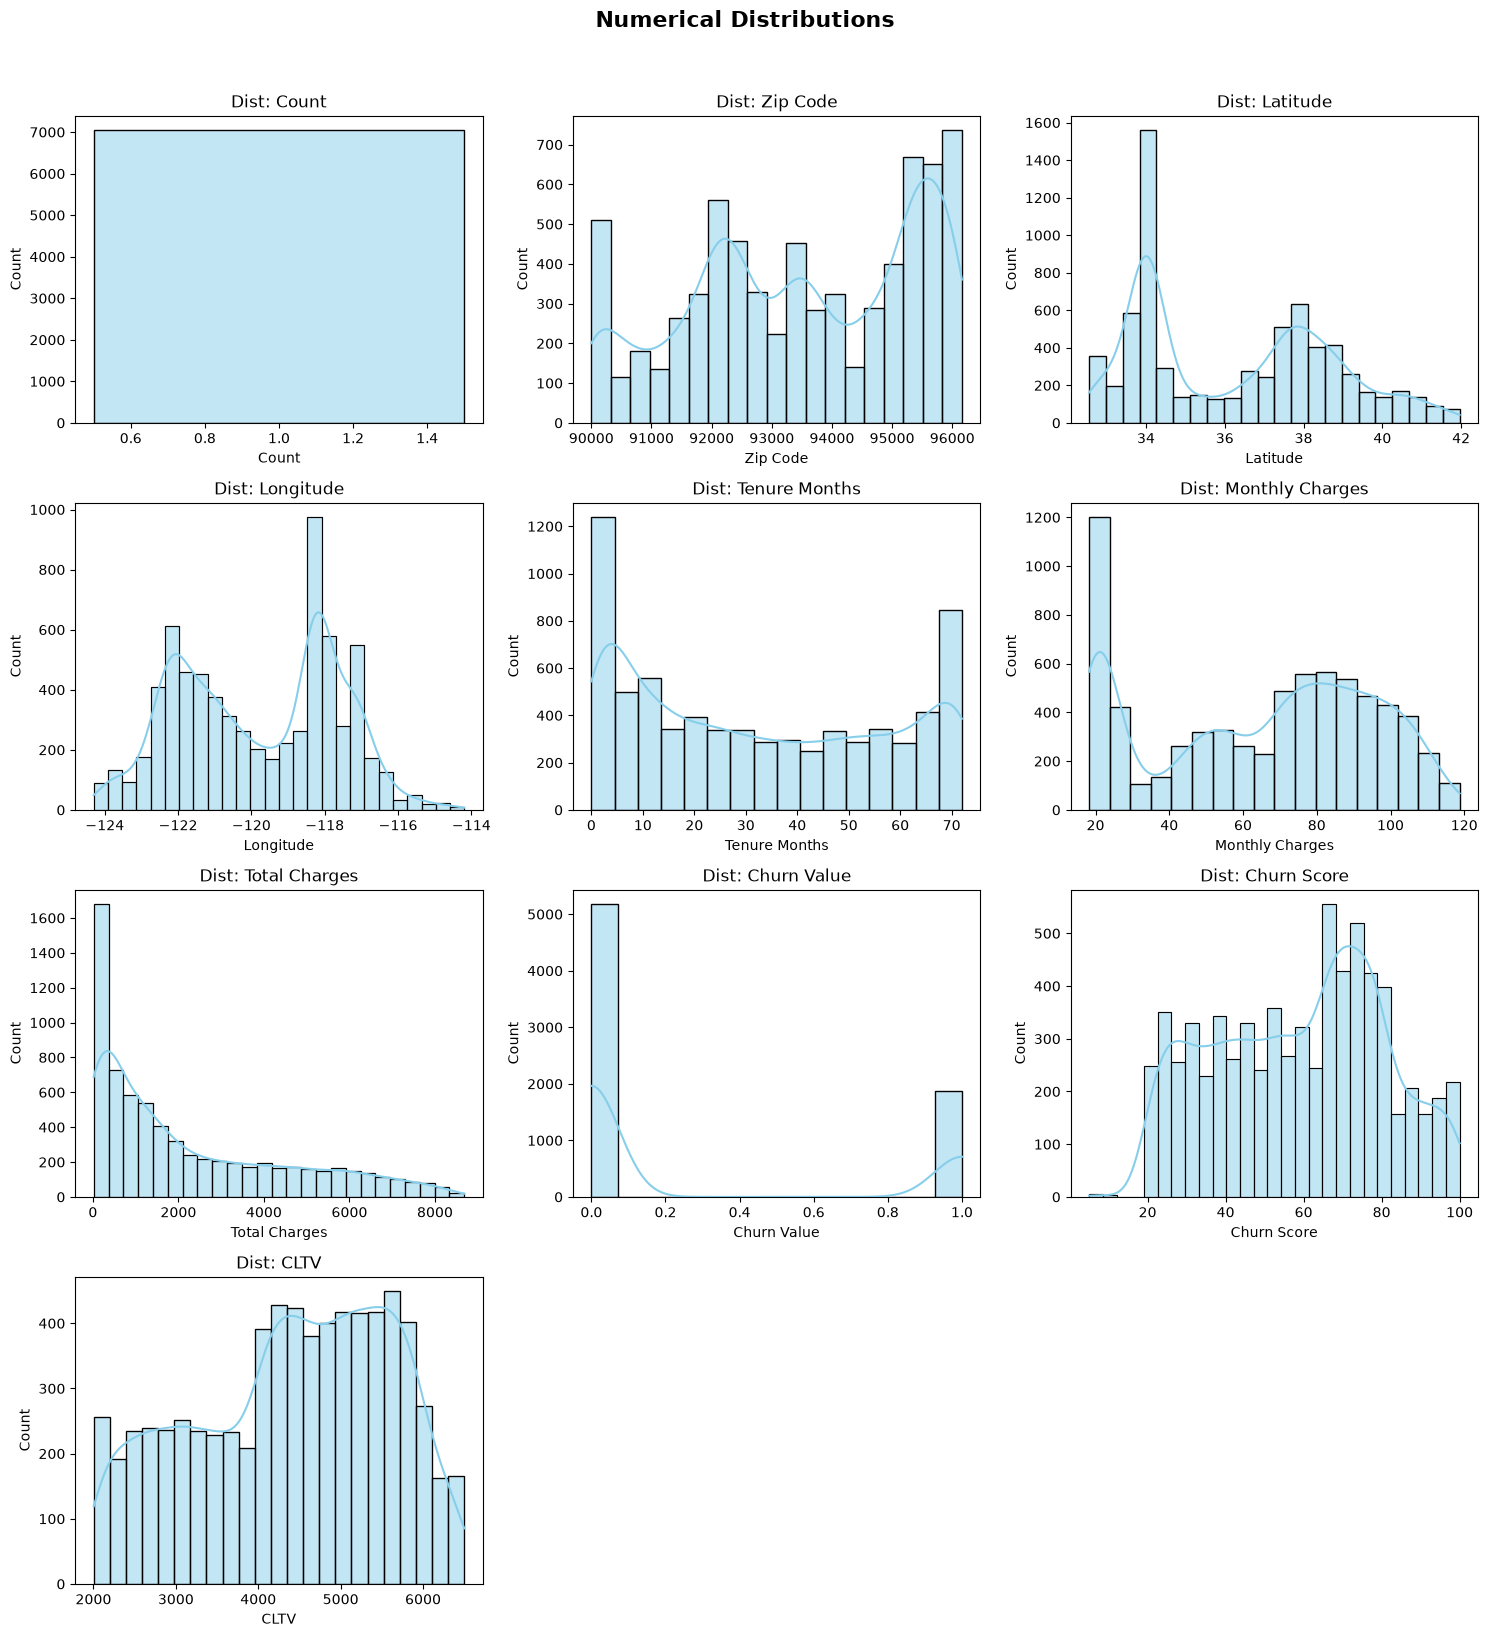

In [10]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(exclude=['int64', 'float64']).columns.tolist()


# 2. PLOT ALL NUMERICAL COLUMNS IN ONE FRAME
if num_cols:
    num_plots = len(num_cols)
    num_cols_grid = 3  # Set how many columns you want in your visual grid
    num_rows_grid = math.ceil(num_plots / num_cols_grid)
    
    fig, axes = plt.subplots(num_rows_grid, num_cols_grid, figsize=(15, 4 * num_rows_grid))
    axes = axes.flatten()  # Flatten the grid into a 1D array for easy looping
    
    for i, col in enumerate(num_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='skyblue')
        axes[i].set_title(f'Dist: {col}')
    
    # Hide any unused blank subplots at the end of the grid
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.suptitle("Numerical Distributions", fontsize=16, weight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

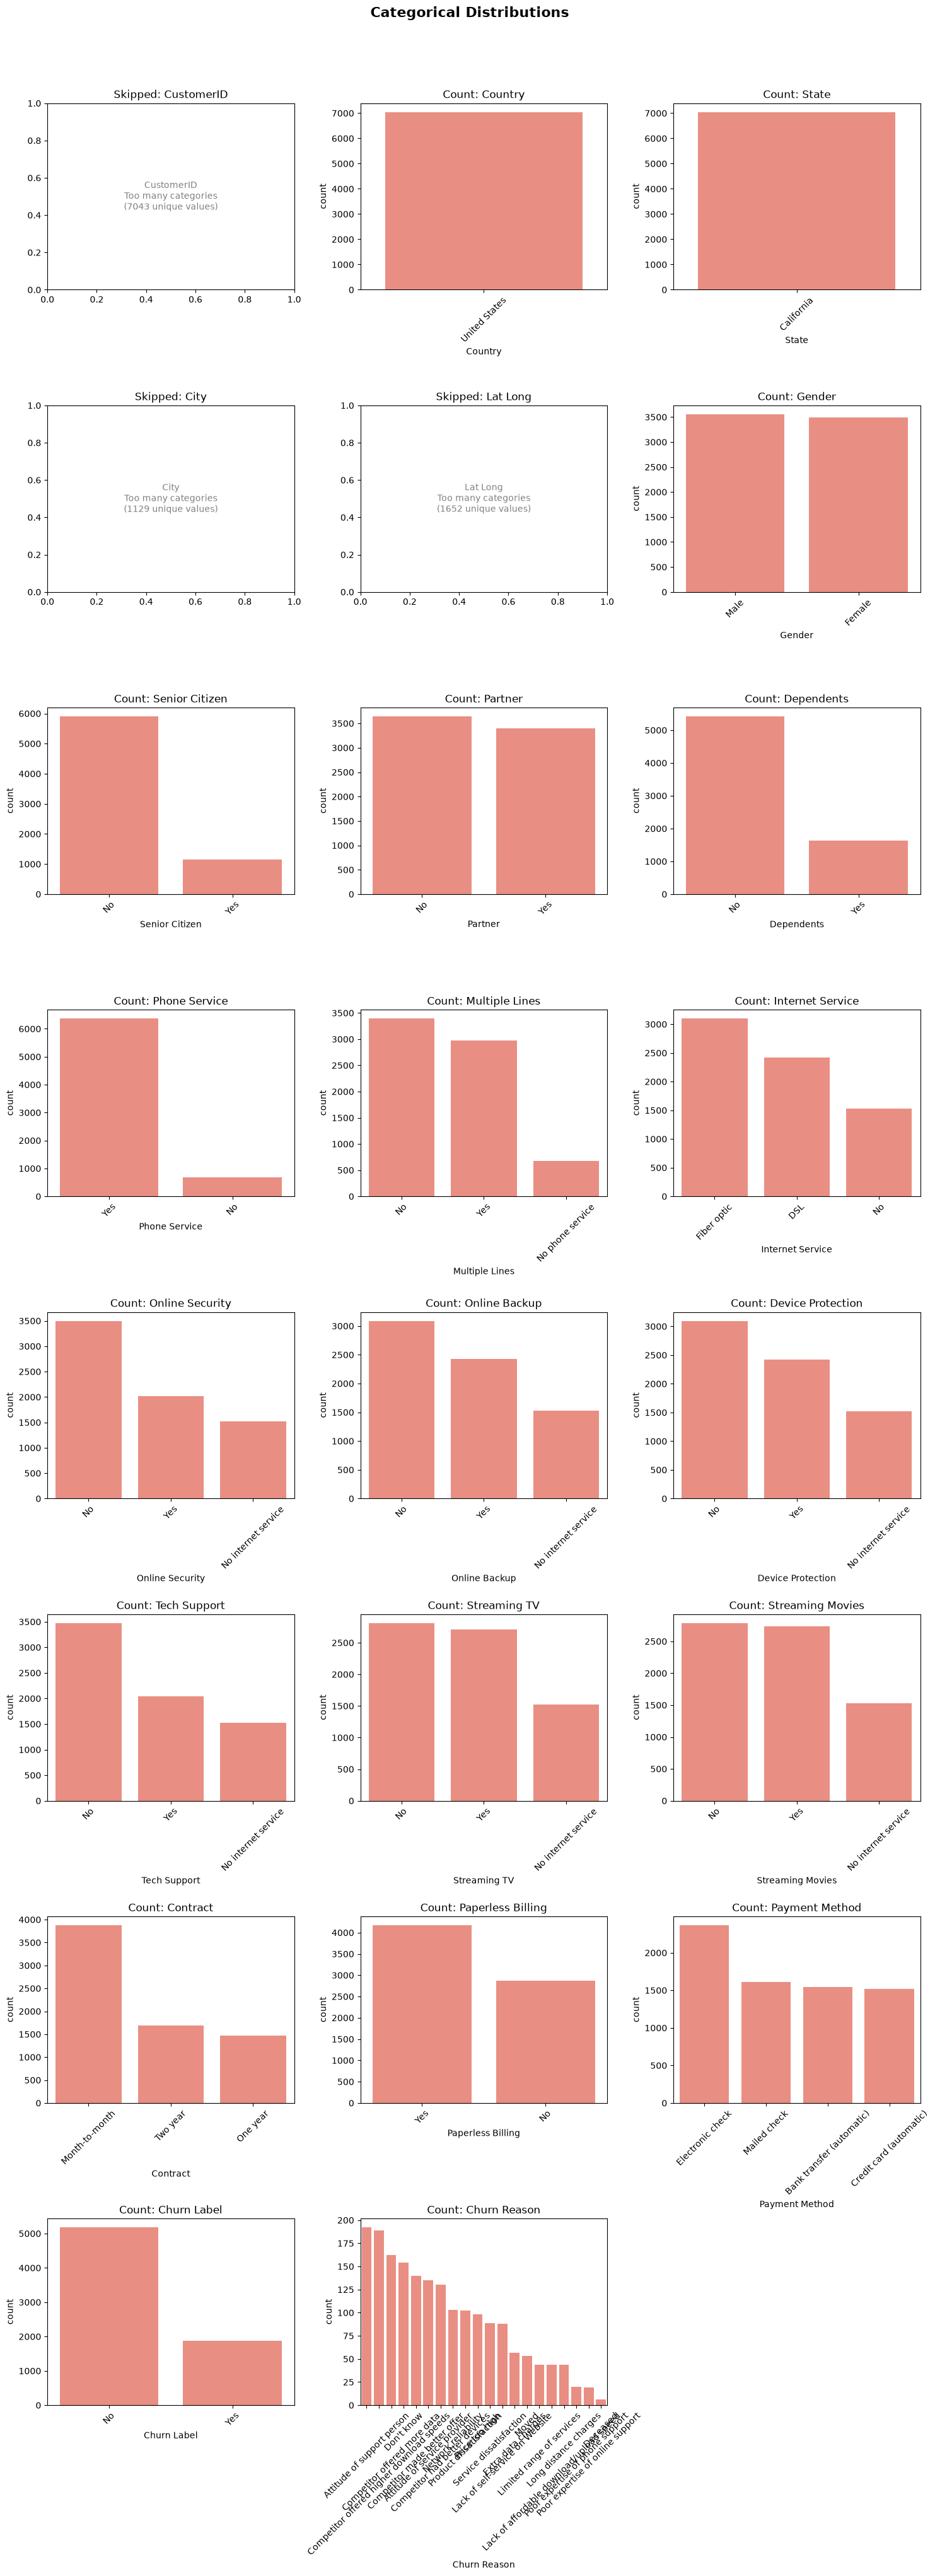

In [11]:
# 3. PLOT ALL CATEGORICAL COLUMNS IN ONE FRAME
if cat_cols:
    cat_plots = len(cat_cols)
    cat_cols_grid = 3  # Set how many columns you want in your visual grid
    cat_rows_grid = math.ceil(cat_plots / cat_cols_grid)
    
    fig, axes = plt.subplots(cat_rows_grid, cat_cols_grid, figsize=(15, 5 * cat_rows_grid))
    axes = axes.flatten()
    
    for i, col in enumerate(cat_cols):
        # Only plot if the column has a reasonable number of categories (e.g., less than 30)
        if df[col].nunique() <= 30:
            sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=axes[i], color='salmon')
            axes[i].set_title(f'Count: {col}')
            axes[i].tick_params(axis='x', labelrotation=45)
        else:
            axes[i].text(0.5, 0.5, f'{col}\nToo many categories\n({df[col].nunique()} unique values)', 
                         ha='center', va='center', fontsize=10, color='gray')
            axes[i].set_title(f'Skipped: {col}')
    
    # Hide any unused blank subplots at the end of the grid
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.suptitle("Categorical Distributions", fontsize=16, weight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

first addjusting datatypes

### Relation wihh target

/var/folders/mc/x59j3q5924sby1mf7q1fdslm0000gq/T/ipykernel_12785/288649503.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET, y=col, ax=axes[i], palette='Set2')
/var/folders/mc/x59j3q5924sby1mf7q1fdslm0000gq/T/ipykernel_12785/288649503.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET, y=col, ax=axes[i], palette='Set2')
/var/folders/mc/x59j3q5924sby1mf7q1fdslm0000gq/T/ipykernel_12785/288649503.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET, y=col, ax=axes[i], palette='Set2')
/

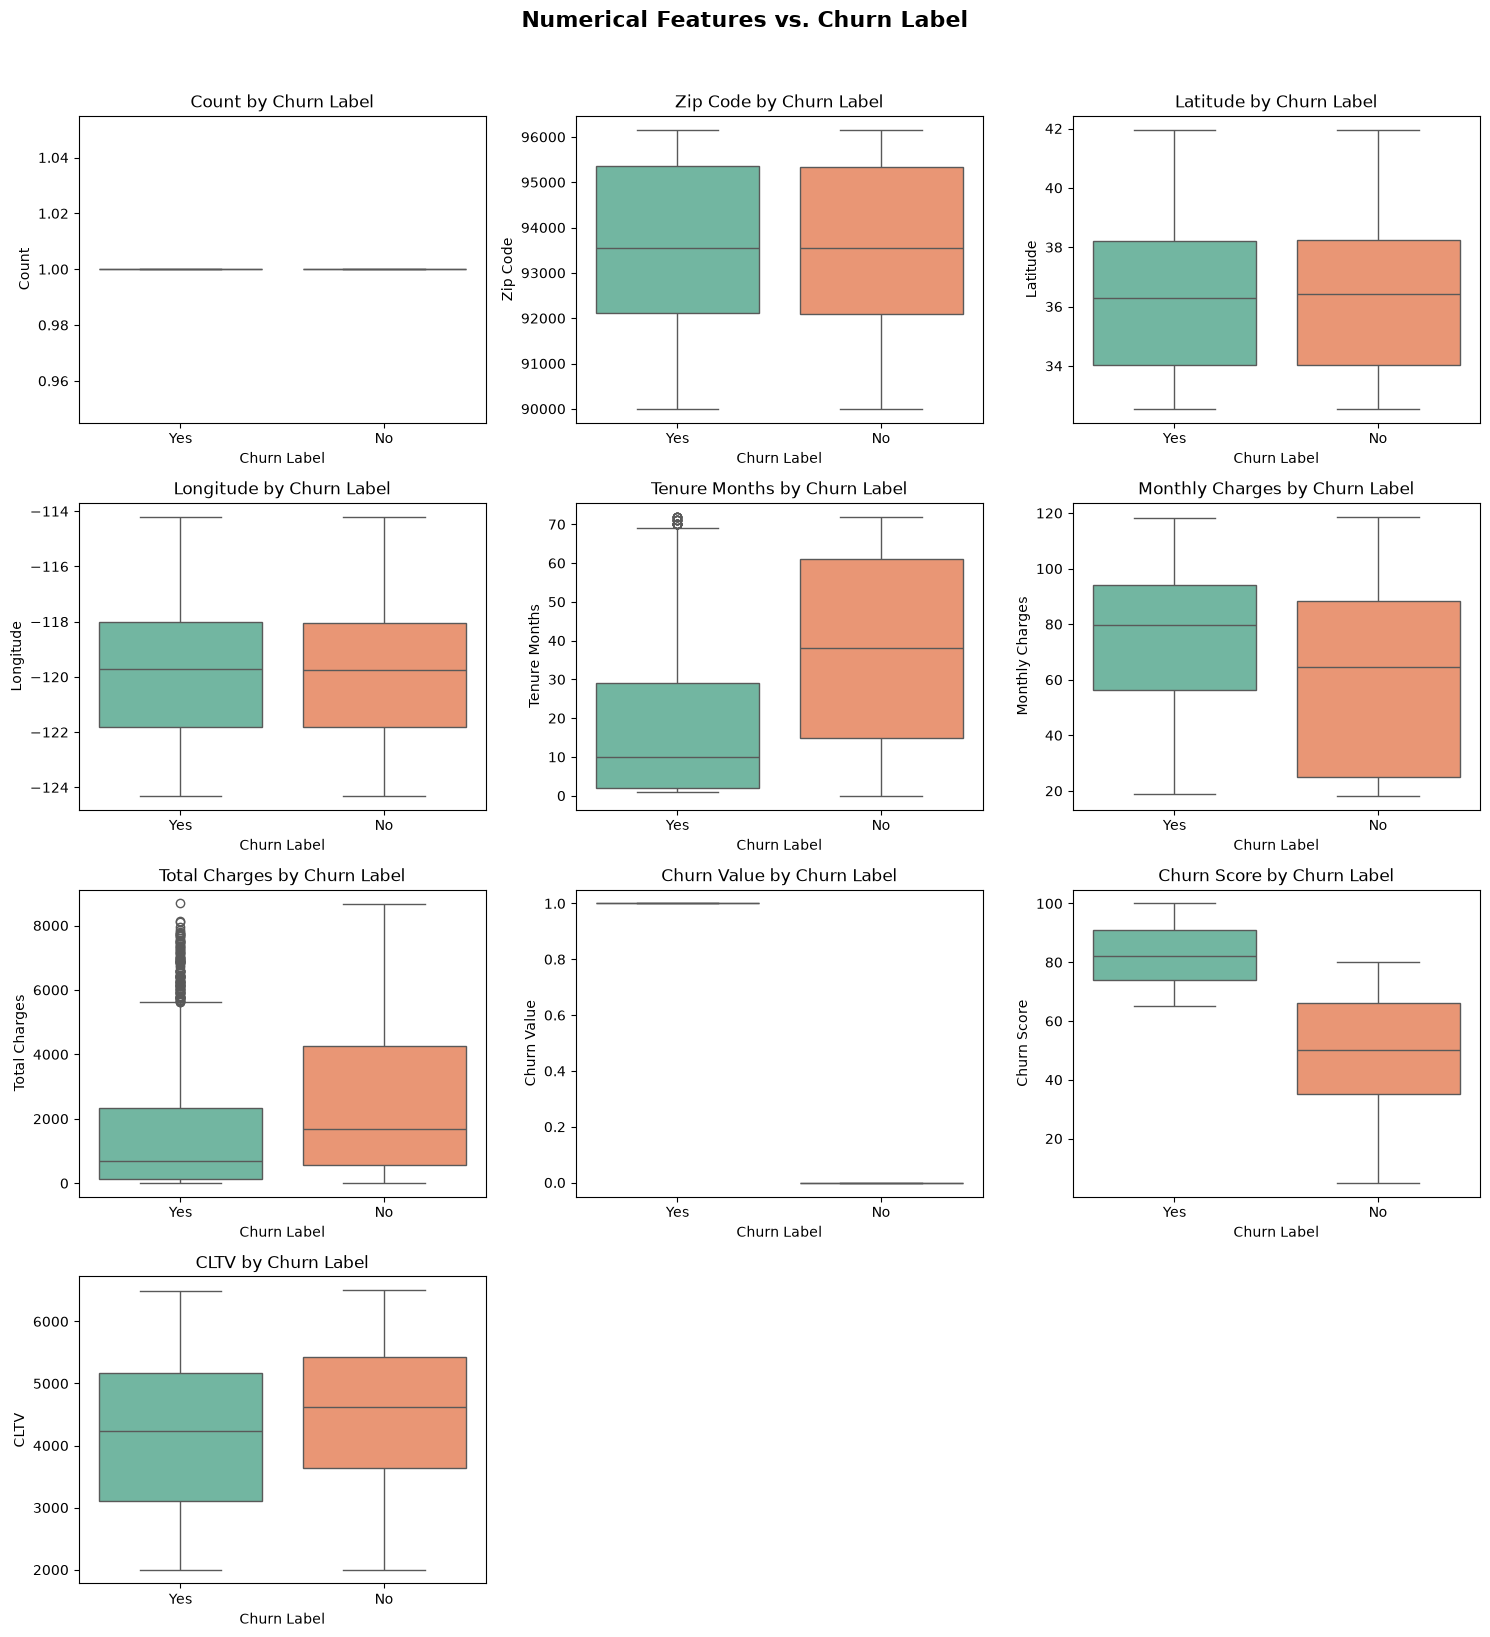

In [12]:
TARGET = 'Churn Label' 

# Separate features, excluding the target itself
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop(TARGET, errors='ignore').tolist()
cat_cols = df.select_dtypes(exclude=['int64', 'float64']).columns.drop(TARGET, errors='ignore').tolist()

# 1. NUMERICAL vs. CATEGORICAL TARGET (Boxplots in one frame)
if num_cols:
    cols_grid = 3
    rows_grid = math.ceil(len(num_cols) / cols_grid)
    fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(15, 4 * rows_grid))
    axes = axes.flatten()
    
    for i, col in enumerate(num_cols):
        # Boxplot shows median and distribution shifts across target classes
        sns.boxplot(data=df, x=TARGET, y=col, ax=axes[i], palette='Set2')
        axes[i].set_title(f'{col} by {TARGET}')
        
    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
    plt.suptitle(f"Numerical Features vs. {TARGET}", fontsize=16, weight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

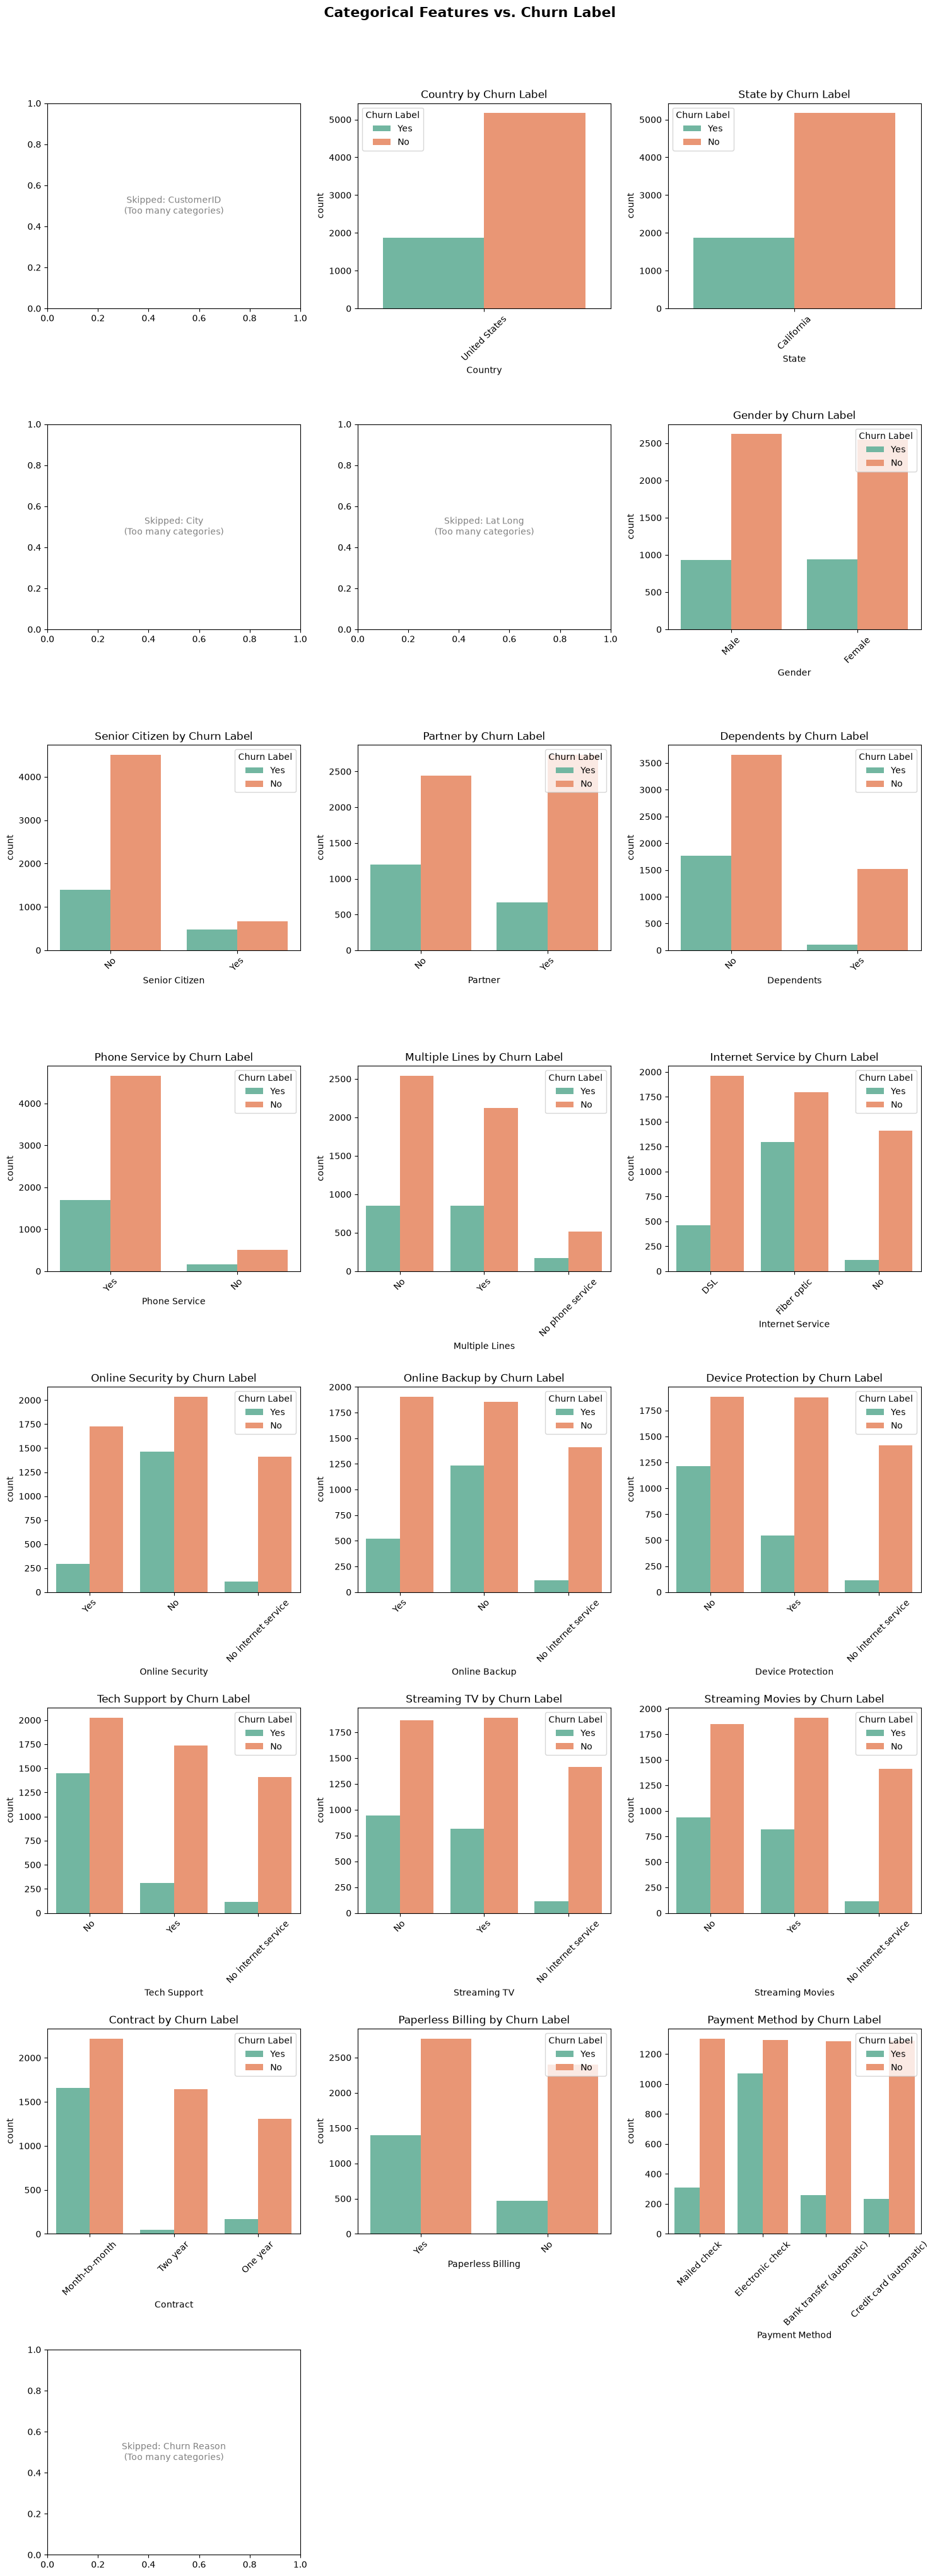

In [13]:
# 2. CATEGORICAL vs. CATEGORICAL TARGET (Grouped Countplots in one frame)
if cat_cols:
    cols_grid = 3
    rows_grid = math.ceil(len(cat_cols) / cols_grid)
    fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(15, 5 * rows_grid))
    axes = axes.flatten()
    
    for i, col in enumerate(cat_cols):
        if df[col].nunique() <= 15:
            # 'hue' splits the bars by your target classes
            sns.countplot(data=df, x=col, hue=TARGET, ax=axes[i], palette='Set2')
            axes[i].tick_params(axis='x', labelrotation=45)
            axes[i].set_title(f'{col} by {TARGET}')
        else:
            axes[i].text(0.5, 0.5, f'Skipped: {col}\n(Too many categories)', ha='center', va='center', color='gray')
            
    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
    plt.suptitle(f"Categorical Features vs. {TARGET}", fontsize=16, weight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

### Part B1:

Add at least 3 encoded/engineeried  features


Main base features:
- contract
- monnthly. charges
- total charges
- tenure 

### Feature engineer columns

In [14]:
df.isnull().sum() #total charges. have. nnull values we. have to deal withh that

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges          11
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [15]:
df[df["Total Charges"].isnull()]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,No,Yes,No,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,No,No,No,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,No,Yes,No,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,No,Yes,No,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No,0,30,4740,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No,0,53,2019,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No,0,49,2299,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No,0,27,3763,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No,0,69,4890,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No,0,44,2342,NaN


In [16]:
# first we. have to fill thhe total. chharges missing values. with appropriate strategy
# it cannaot simply filled my mean or median. something beacuse it may differ based on contracts or monthly charges
# onne thing is noticed is that all customers. havig total charges null have tenure months 0 it means. they are new customers
# so i am going with approach that to. assign total charges 0 dollors as they. are. new. customers. thats why they have no current total charges
#it. can also inddicate a relation new customers with total chharges may churn


df.loc[
    df["Total Charges"].isna() &
    (df["Tenure Months"] == 0),
    "Total Charges"
] = 0

In [17]:
# next feature engineer new columns
#creatinng tenuure bucket so we can get relation if small bucket tenure may more likely to churn
df["tenure_bucket"] = pd.cut(
    df["Tenure Months"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"]
)

In [18]:
df["charge_per_tenure"] = (
    df["Monthly Charges"] /
    (df["Tenure Months"] + 1)
)

In [19]:
service_columns = [
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    
    "Streaming Movies"
]

df["num_additional_services"] = (
    df[service_columns]
    .apply(lambda row: (row == "Yes").sum(), axis=1)
)

In [20]:
df.sample(7)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,tenure_bucket,charge_per_tenure,num_additional_services
7012,0052-YNYOT,1,United States,California,Calexico,92231,"32.690654, -115.431225",32.690654,-115.431225,Female,No,No,No,67,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Electronic check,20.55,1343.40,No,0,72,5462,NaN,49-72,0.302206,0
4771,4797-MIWUM,1,United States,California,Goleta,93117,"34.489983, -120.091246",34.489983,-120.091246,Male,No,Yes,Yes,7,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),20.25,174.70,No,0,42,3149,NaN,0-12,2.531250,0
2625,9391-TTOYH,1,United States,California,Oakland,94611,"37.828416, -122.216005",37.828416,-122.216005,Female,No,No,No,23,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,19.50,470.20,No,0,42,5652,NaN,13-24,0.812500,0
190,5842-POCOP,1,United States,California,Randsburg,93554,"35.405722, -117.773354",35.405722,-117.773354,Female,No,Yes,No,5,Yes,No,Fiber optic,Yes,No,Yes,No,No,Yes,Month-to-month,Yes,Mailed check,88.90,454.15,Yes,1,79,4356,Competitor offered higher download speeds,0-12,14.816667,3
5472,1215-EXRMO,1,United States,California,Junction City,96048,"40.913192, -123.06597",40.913192,-123.065970,Male,No,Yes,No,50,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.55,1067.65,No,0,78,4745,NaN,49-72,0.402941,0
2352,9574-BOSMD,1,United States,California,Arvin,93203,"35.116307, -118.817644",35.116307,-118.817644,Male,No,Yes,Yes,68,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),25.40,1620.20,No,0,72,5668,NaN,49-72,0.368116,0
4522,9447-YPTBX,1,United States,California,Alhambra,91801,"34.090925, -118.128164",34.090925,-118.128164,Female,No,Yes,No,50,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Bank transfer (automatic),19.85,943.10,No,0,39,4358,NaN,49-72,0.389216,0


In [21]:
# final. fetures we will be using in part c

numeric_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "charge_per_tenure",
    "num_additional_services"
]

categorical_features = [
    "tenure_bucket",
    "Contract"
]

### Part B3 Building baseline moddel

In [22]:
# first we. make baseeline model with. simple base features not enginnered
#then will comapre model withh eengineerd featuures

y = (df["Churn Label"] == "Yes").astype(int)

baseline_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]

X = df[baseline_features].copy()

In [23]:
print(X.isna().sum())

Tenure Months      0
Monthly Charges    0
Total Charges      0
dtype: int64


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
) # stratify = y ensure eachh split (train and test) get approx equal amount of target column ratio



In [25]:
print("Overall churn rate:",
      y.mean())

print("Training churn rate:",
      y_train.mean())

print("Test churn rate:",
      y_test.mean())


#The dataset was divided into 80% training and 20% test data using stratified sampling. The churn proportion remained approximately consistent across the overall, training, and test datasets.

Overall churn rate: 0.2653698707936959
Training churn rate: 0.2653532126375577
Test churn rate: 0.2654364797728886


In [26]:
# making baseline model pipeline
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

#using standard scalar as our numeric column have outliers so it handdle this by making mean. 0 and std dev -1 to 1

baseline_model.fit(X_train, y_train) 



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['Tenure Months','Monthly Charges','Total Charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [27]:
baseline_preds = baseline_model.predict(X_test)

print( classification_report(
        y_test,
        baseline_preds
    )
)

              precision    recall  f1-score   support

           0       0.81      0.90      0.85      1035
           1       0.60      0.42      0.49       374

    accuracy                           0.77      1409
   macro avg       0.71      0.66      0.67      1409
weighted avg       0.76      0.77      0.76      1409



In [28]:
#. saving the basline metrics
baseline_precision = precision_score(
    y_test,
    baseline_preds
)

baseline_recall = recall_score(
    y_test,
    baseline_preds
)

baseline_f1 = f1_score(
    y_test,
    baseline_preds
)

print(f"Precision: {baseline_precision:.3f}")
print(f"Recall:    {baseline_recall:.3f}")
print(f"F1:        {baseline_f1:.3f}")

Precision: 0.602
Recall:    0.420
F1:        0.494


### Part B4 Cross validating baseline moddel

In [29]:
# checking if our f1 score is stable across differnet splits ratio or is it only occur for 80 , 20 split

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("F1 scores:", cv_scores)

print(
    f"Mean F1: {cv_scores.mean():.3f} "
    f"+/- {cv_scores.std():.3f}"
)

F1 scores: [0.52140078 0.51272016 0.53386454 0.5377176  0.536     ]
Mean F1: 0.528 +/- 0.010


## now with enginnered columns:




In [30]:
preprocess = ColumnTransformer([
    (
        "num",
        StandardScaler(),
        numeric_features
    ),
    (
        "cat",
        OneHotEncoder(
            handle_unknown="ignore"
        ),
        categorical_features
    )
])

engineered_model = Pipeline([
    ("prep", preprocess),
    (
        "clf",
        LogisticRegression(
            max_iter=1000
        )
    )
])

In [31]:
X_full = df[
    numeric_features +
    categorical_features
].copy()

In [32]:
y = (
    df["Churn Label"] == "Yes"
).astype(int)

In [33]:
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [34]:
engineered_model.fit(
    X_train_full,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Tenure Months','Monthly Charges','Total Charges',..., 'num_additional_services','tenure_bucket','Contract']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [35]:
engineered_preds = engineered_model.predict(
    X_test_full
)

engineered_precision = precision_score(
    y_test,
    engineered_preds
)

engineered_recall = recall_score(
    y_test,
    engineered_preds
)

engineered_f1 = f1_score(
    y_test,
    engineered_preds
)

print(f"Precision: {engineered_precision:.3f}")
print(f"Recall:    {engineered_recall:.3f}")
print(f"F1:        {engineered_f1:.3f}")

Precision: 0.655
Recall:    0.452
F1:        0.535


In [36]:
# baseline f1 score vs enginnered features f1 score
print(
    f"Baseline F1:    {baseline_f1:.3f}"
)

print(
    f"Engineered F1:  {engineered_f1:.3f}"
)

print(
    f"F1 improvement: "
    f"{engineered_f1 - baseline_f1:.3f}"
)

Baseline F1:    0.494
Engineered F1:  0.535
F1 improvement: 0.040


here we can clearly see that engineeried columnns. has greater f1 score than normal basline features

## B2 — Error analysis

In [37]:
wrong = X_test_full[
    engineered_preds != y_test
].copy()

wrong["true"] = y_test[
    engineered_preds != y_test
]

wrong["pred"] = engineered_preds[
    engineered_preds != y_test
]

In [38]:
print(
    wrong.sample(
        min(30, len(wrong)),
        random_state=1
    )
)

      Tenure Months  Monthly Charges  Total Charges  charge_per_tenure  \
440              46            96.05        4399.50           2.043617   
949               4            20.95          85.50           4.190000   
750              61            99.15        6010.05           1.599194   
120              15            69.00         994.80           4.312500   
857              19           100.95        1875.55           5.047500   
252              33            80.60        2656.50           2.370588   
3222              8            74.85         572.45           8.316667   
227               1            24.60          24.60          12.300000   
1286             36            90.85        3186.70           2.455405   
47                1            24.80          24.80          12.400000   
303              60            94.40        5610.25           1.547541   
1116              3            19.60          59.75           4.900000   
1147             55            57.55  

i have observedd that customers with monthhly contract relatively high total charges andd highh tenure months are preddicted wrong.

In [41]:
# Save dataset with selected features + target

selected_columns = X_full.columns.tolist() + ["Churn Value"]

model_df = df[selected_columns].copy()

# Check
print("Shape:", model_df.shape)
display(model_df.head())

Shape: (7043, 8)


,Tenure Months,Monthly Charges,Total Charges,charge_per_tenure,num_additional_services,tenure_bucket,Contract,Churn Value
0,2,53.85,108.15,17.950000,2,0-12,Month-to-month,1
1,2,70.70,151.65,23.566667,0,0-12,Month-to-month,1
2,8,99.65,820.50,11.072222,3,0-12,Month-to-month,1
3,28,104.80,3046.05,3.613793,4,25-48,Month-to-month,1
4,49,103.70,5036.30,2.074000,4,49-72,Month-to-month,1


In [42]:
model_df.to_csv("../data/churn_model_dataset.csv", index=False)